<a href="https://colab.research.google.com/github/Mjmo/Ptethesis_Project/blob/main/IFCB_NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IFCB project
### Finetuning a model for classifying Phytoplankton images
Developed for the module Projekt M.Sc. Information Technology University of Rostock

#1. Introduction
This project builds upon prior research conducted in Finland, in which a ResNet18 model was fine-tuned on phytoplankton images acquired using the Imaging FlowCytobot (IFCB). The IFCB system generates a very large volume of image data, creating a substantial need for automated and efficient classification methods. In the Finnish study, deep learning techniques were successfully applied to address this large-scale classification challenge.
link to the study [Towards operational phytoplankton recognition with automated high-throughput imaging, near-real-time data processing, and convolutional neural networks](https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2022.867695/full#B45).
The objective of the present work is to classify phytoplankton images collected with the same IFCB technology at the ([Leibniz Institute for Baltic Sea Research Warnemünde](https://www.iow.de/de_index.html)) Therefore, the Finnish research is highly relevant to this project for several reasons.

First, both studies rely on the same imaging instrument, which ensures comparable image characteristics such as resolution, contrast, and background structure. Second, there is significant morphological similarity among phytoplankton species in the Baltic Sea region. Many species exhibit similar shapes, textures, and structural features, making transfer learning particularly suitable. Additionally, four classes used to train the Finnish model are also present in the dataset provided by the IOW. This overlap further supports the applicability of the pretrained model to our classification task.

Consequently, the Finnish study provides a strong methodological and practical foundation for this project. It demonstrates the effectiveness of fine-tuning a ResNet18 model for large-scale phytoplankton image classification and offers a promising starting point for adapting the approach to the IOW dataset.

#2. Setup and requirments installation
##2.1. Cloning the project and installing the requirements
The first step in setting up the project is to clone our source code from the GitHub repository. This ensures that all necessary files, scripts, and configuration settings are available locally.

To clone the repository, run the following command in the terminal:

In [1]:
!git clone https://github.com/Mjmo/Ptethesis_Project.git

Cloning into 'Ptethesis_Project'...
remote: Enumerating objects: 428, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 428 (delta 78), reused 83 (delta 40), pack-reused 303 (from 1)
Receiving objects: 100% (428/428), 82.88 MiB | 17.12 MiB/s, done.
Resolving deltas: 100% (252/252), done.


All libraries specified in the requirements.txt file are installed to ensure that the project executes correctly and all required dependencies are available.

In [2]:
!pip install -r "/content/Ptethesis_Project/requiremnts.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 144.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814

This command is installing the project as a Python package so we can import the modules from it|

In [1]:
!pip install -e /content/Ptethesis_Project

Obtaining file:///content/Ptethesis_Project
  Preparing metadata (setup.py) ... done
  Running setup.py develop for IFCB_PROJECT


In [2]:
cd /content/Ptethesis_Project/src

/content/Ptethesis_Project/src


##2.2 Importing the python modules
We organized the code into modules and submodules to ensure scalability and simplicity. Below, we explain the key imports and their functionalities:

- EDA Module
Contains the Display submodule, which provides two main functions:

  - **plot_class_distribution** Plots the distribution of the classes in our dataset, helping to visualize class imbalance.

  - **plot_dataset_samples_randomly** Randomly selects and displays sample images from the dataset for qualitative inspection.
- transforms from torchvision – Imported to perform image preprocessing and data augmentation for both the training and test datasets. These transformations include resizing, normalization, and optional augmentations to improve model generalization.

- **load_config** from the config module – Used to load the configuration settings and hyperparameters for the model, training process, and dataset. All parameters are specified in the configuration file:
**Prethesis_Project/src/configs/experiment_config.yaml**.
- from the module mydata we imported the submodule gettraintest that provides the functions
  - **get_datset** that return the dataset of the images
  - **get_data_loader** Returns two PyTorch DataLoaders (train and test) and handles:
    - Splitting dataset into train/test sets
    - Augmenting underrepresented classes in the training set
    - Applying augmentation to the rest of the training set and the test set
  The returned objects are ready for training and evaluation.
- from the module train we import the submodule utils that provides utility functions used in the model process training
  - **compute_class_weight** Calculates class weights to handle imbalanced datasets.
  - **freeze_all_layers** Controls which layers of a ResNet18 model are trainable:
  - **initiate_mlflow** Sets up MLflow tracking:
    - Specifies a directory to save training experiments
    - Records hyperparameters, metrics (loss, accuracy), and other experiment data
    - Makes experiment tracking and comparison easier.
- from the module train we import the submodule train which provides the function **run_experiment** – Conducts and runs the training experiments. Details will be explained in later sections.
- from the module models we import the submodule model which provides the functions
    - **loadpretrainedmodel** Loads the ResNet18 architecture with pretrained weights of the model that were finetuned in Finnland.
    - **addnewhead** laces the model’s fully connected head with a new head:  
       - Dimensions defined by **head_dim** hyperparameter
       - Output layer matches **num_classes** in the dataset
- The module Evaluation contains the modules for evaluating the model after training
  - from the Evaluation module we import the submodule metrics that provide the following functions
    - **validate_mutilclass**: validates the model on the test set after training
    - **plot_confusion_matrix**: allows us to plot the cofusion matrix to know which classes are being confused by the model
    - **plot_learning_curve**: allows the user to plot the curve of training and validation loss and the curve of training and validation accuracy with regard to the epochs
    - **show_misclassified**:plot the samples that the model couldn't correctly classify
    - **save_classification_repor**t:plot the classification report which shows the precision, recall and F1-score of each class
  - from the Evaluation module we import the submodule EXA that provides the **implement_integrated** function that allows us to apply integrated gradients which is an explainable artificial intelliegence methid


In [7]:
# Exploratory Data Analysis (EDA) module.
# This module includes a Display submodule that:
# - Plots the class distribution of the dataset
# - Randomly visualizes sample images from the dataset
from EDA.display import plot_class_distribution,plot_dataset_samples_randomly
# Importing transformation utilities from torchvision
# to perform data augmentation and preprocessing
from torchvision import transforms
from Evaluation.metrics import plot_learning_curve
from config.load import load_config
from mydata.gettraintest import get_dataset,get_data_loader
from train.utils import compute_class_weights,freeze_all_layers,initate_mlflow
from train.train import run_expirement
import torch
import torchvision
import gdown
from sklearn.metrics import classification_report
from models.model import loadpretrainedmodel,addnewhead
from Evaluation.metrics import validate_multiclass,plot_confusion_matrix,plot_learning_curve,show_misclassified,save_classification_report
import matplotlib.pyplot as plt
from Evaluation.EXA import implement_integrated
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


we load the configuration, The configuration contains all hyperparameters used in the project, divided into sections:
- seed: the seed we want to use it
- data: Hyperparameters for handling the dataset:
  - **train_data_path:** Path to the dataset
  - **test_size**: Fraction of the dataset reserved for testing (float < 1)
  - **batch_size**: Batch size for training (integer)
  - **min_samples** Minimum number of samples each class must have in the training set
- model: Hyperparameters for the model:
  - pretrained_weights: Path to  weights of the pretrained model  (finetuned in Finland)
  - **head_dim**: List of integers defining the dimensions of  the layers of the new head
  _ **num_classes**: Number of output classes (integer, dimension of final layer)
- training: : This section contains all hyperparameters related to training the model. It includes:
  - **num_epochs**: The number of epochs to train model.
  - **save_path**: The path where the trained model will be saved.
  - **lr_head**: learning rate for the head parameters
  - **lr_base**: The learning rate applied to the base or backbone layers of the model.

The path of the config file is **Ptethesis_Project/src/configs/expiremnt_config.yaml** and shouldn't be changed moved to another path because parts of the code depends on its path

In [8]:
config=load_config("/content/Ptethesis_Project/src/configs/expiremnt_config.yaml")
data_config=config.data
model_config=config.model
training_config=config.training
seed=config.seed

“We will use CUDA as our device to leverage GPU acceleration during training.”

In [9]:

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

#2. Dataset

The original model, trained in Finland, was trained on a **public phytoplankton image dataset**:  
[Public dataset](http://doi.org/10.23728/b2share.abf913e5a6ad47e6baa273ae0ed6617a)  
 - This dataset contains phytoplankton images captured using the Imaging FlowCytobot (IFCB).
 - It comprises 63,000 images spanning 50 phytoplankton types.
 - The model was evaluated on a separate, public evaluation dataset:, **public evaluation dataset**:  
[Evaluation Dataset ](http://doi.org/10.23728/b2share.7c273b6f409c47e98a868d6517be3)
 - This evaluation dataset contains 150,000 images from an annual IFCB deployment at the Utö Atmospheric and Marine Research Station (Baltic Sea).
 - It has the same number of classes (50) and also includes a class for images labeled as unclassifiable
- For this project, we will **fine-tune the model** on our own dataset, which was provided by the :  
[**Institute for Baltic Sea Research (IOW)**](https://www.iow.de/de_index.html)
  - Our dataset contains 5,640 images of phytoplankton across 43 classes.
  - 3 classes were removed because they contained only a single image each.


## 2.1 Downloading the datsets
Before training, we need to load our dataset. The workflow is as follows:
- **Download and unzip our dataset:**
  - The dataset is provided via a Google Drive link.
  - After downloading, we will unzip the files to access the images
- **Downloading the orginal Dataset**
  - We will load the original phytoplankton dataset the model was trained on to identify the common classes between it and our own dataset.


In [10]:
#the id of our dataset in Google drive
IOW_dataset_id="12zXNs_VUAtSxsfpa5_6-DZ2v1Ad4-pnn"
url = f'https://drive.google.com/uc?id={IOW_dataset_id}'
gdown.download(url, 'dataset.zip', quiet=False)
!unzip -q "/content/Ptethesis_Project/src/dataset.zip" -d /content/IOW_dataset
!rm "/content/Ptethesis_Project/src/dataset.zip"

Downloading...
From (original): https://drive.google.com/uc?id=12zXNs_VUAtSxsfpa5_6-DZ2v1Ad4-pnn
From (redirected): https://drive.google.com/uc?id=12zXNs_VUAtSxsfpa5_6-DZ2v1Ad4-pnn&confirm=t&uuid=e5801f8c-02e2-46c9-84b0-d85830aa9c5f
To: /content/Ptethesis_Project/src/dataset.zip
100%|██████████| 315M/315M [00:02<00:00, 128MB/s]


replace /content/IOW_dataset/Skeletonema_marinoi/D20240314T063931_IFCB197_00401.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [11]:
#id of the orginal dataset
orginal_dataset="1Y9pQuViUIVK-qyj2Xqiz9xPh1mzYHABe"
url = f'https://drive.google.com/uc?id={orginal_dataset}'
gdown.download(url, 'orginal_dataset.zip', quiet=False)
!unzip -q "/content/Ptethesis_Project/src/orginal_dataset.zip" -d /content/orginal_dataset
!rm "/content/Ptethesis_Project/src/orginal_dataset.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1Y9pQuViUIVK-qyj2Xqiz9xPh1mzYHABe
From (redirected): https://drive.google.com/uc?id=1Y9pQuViUIVK-qyj2Xqiz9xPh1mzYHABe&confirm=t&uuid=43ee85b8-d5e8-4c1c-a130-c36555403ef1
To: /content/Ptethesis_Project/src/orginal_dataset.zip
100%|██████████| 509M/509M [00:08<00:00, 57.5MB/s]


##2.2 Exploratory Data Analysis
### 2.2.1 Loading the datasets
To load the datasets, we use the get_dataset function, which takes a path as input and returns a dataset instance of the class **torchvision.datasets.ImageFolde**r. The path to the training data can be specified in the configuration file located at: **Ptethesis_Project/src/configs/expiremnt_config.yaml**

In [12]:
IOW_dataset_path=data_config.train_data_path
IOW_dataset=get_dataset(IOW_dataset_path)
orginal_dataset="/content/orginal_dataset/labeled_20201020"
orginal_dataset=get_dataset(orginal_dataset)
evaluation_subset_path="/content/subset/content/Testsample/phytoplankton_Utö_2021_labeled"

### 2.2.2 Exploring the common classes between our dataset and the orginal one
To understand the overlap between our dataset and the original dataset on which the model was trained, we identify the common classes. This is done by computing the intersection between the set of classes in our dataset and the set of classes in the original dataset.

In [13]:
IOW_CLASSES=set(IOW_dataset.classes)
finish_CLASSES=(orginal_dataset.classes)
IOW_CLASSES.intersection(finish_CLASSES)

{'Dolichospermum-Anabaenopsis',
 'Licmophora_sp',
 'Nodularia_spumigena',
 'Skeletonema_marinoi'}

Only 4 classes are common between the two datasets The classes **Dolichospermum-Anabaenopsis** ,**Licmophora_sp** **Nodularia_spumigena** and **Skeletonema_marinoi** are common in both classes

### 2.2.3 plotting samples of our dataset
First, we define a dictionary that maps the dataset labels to their corresponding class names. Next, we use the function plot_dataset_samples_randomly, which takes the following arguments:

- dataset – the dataset to be visualized

- cls –A dictionart that maps dataset labels to class names

- seed – for reproducibility

Additionally, the function supports optional arguments with default values:

- num_images – the number of images to plot with default value 8

- num_rows – the number of rows in which to display the images with default value 2

- fig_size – the size of the figure with default value (8,8)

In [14]:
#dictionary that maps labels to the class names
idx_to_cls={v:k for k,v in IOW_dataset.class_to_idx.items()}


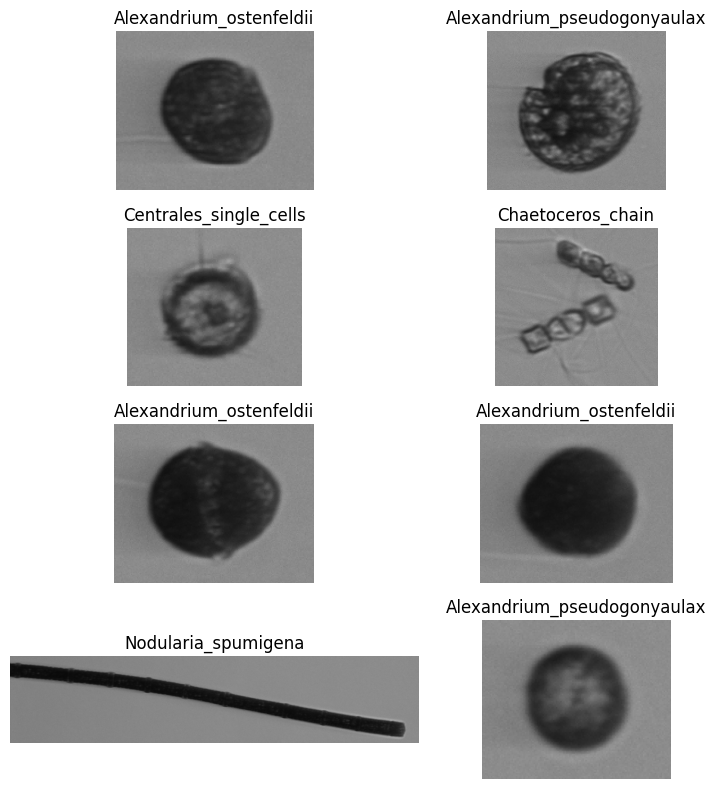

In [15]:
plot_dataset_samples_randomly(IOW_dataset,idx_to_cls,seed=222)

We will visualize the distribution of classes in our dataset and the original dataset.

To do this, we will use the **plot_class_distribution** function, which requires two arguments:

- dataset – The dataset whose class distribution we want to analyze.
- class_names – A list of the names of the classes in the dataset.
This function will generate a plot showing the number of samples per class, helping us understand class imbalance and coverage in our dataset.



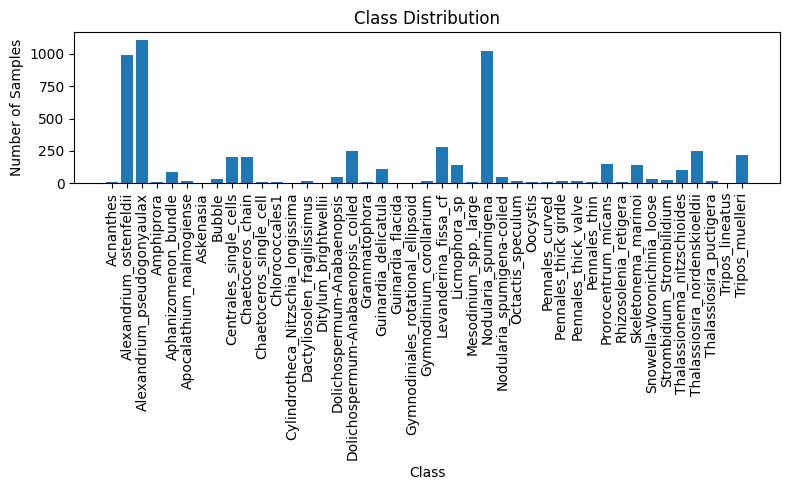

In [16]:
plot_class_distribution(IOW_dataset,IOW_dataset.classes)


As we can see, the dataset exhibits a strong class imbalance. The class **Alexandrium_pseudogonyaulax** has the largest number of samples, which presents additional challenges that we will need to address during training, such as ensuring the model does not become biased toward overrepresented classes.

## 2.3 Defining data augmentations

We will define data augmentations for both the training and test sets. The augmentations applied will be the same of  those used by the researchers in the original model, as they are well-suited for this type of image data.

**Training Set Augmentations**
- Resize the images to a fixed size of (180, 180)
- Apply a random rotation of up to ±10 degrees
- Apply random brightness variation between 95% and 100%
- Apply random scaling of the images between 60% and 140%
- Convert the image to Tensor

**Test Set Augmentations**
- Resize the images to a fixed size of (180, 180)
- Convert the image to Tensor


In [17]:

train_aug = transforms.Compose([
    transforms.Resize(size=(180,180)),  # random zoom                 # microscopy can be symmetric
    transforms.RandomRotation(degrees=10),                # larger rotation range
    transforms.ColorJitter(brightness=(0.95,1)), # intensity variation
    transforms.RandomAffine(                            # small shifts
        scale=(0.6, 1.4),degrees=0
    ),
    transforms.ToTensor()

])

valid_aug = transforms.Compose([
    transforms.Resize((180,180)),
    transforms.ToTensor()
])

## 2.4 Getting the train and validation data loaders
To prepare the data for training and obtain the data loaders, we use the function **get_data_loader**, which takes the following arguments:

1.   dataset – the dataset to be loaded
2.   min_samples – the minimum number of samples each class in the training set must have
3. train_aug – data augmentations applied to the training set
4. valid_aug – data augmentations applied to the validation/test set
5. batch_size: batch_size – the batch size for both training and validation loaders
6. test_size – the fraction of the dataset to reserve for validation, as a float between 0 and 1
7. num_workers – the number of subprocesses used by the DataLoader to load data in parallel   
**Function Workflow**
- Stratified splitting: The dataset is split into training and validation sets according to test_size hyperparameter, while maintaining the same proportion of each class in both sets.
- Handling minority classes: Classes with fewer samples than min_samples are identified.
- Data augmentation for minority classes: The training augmentations are applied to these minority classes, and the resulting images are added to trainset ensure each class reaches at least min_samples.
- Returning DataLoaders: Two torch.utils.data.DataLoader instances are returned from the function one for training and one for testing.
Since our dataset is relatively small, we will use a test set fraction of 20% (test_size=0.2) to evaluate the model after training. We will not use a separate validation set during training, meaning overfitting will not be explicitly monitored during the training process.

In [18]:

train,val=get_data_loader(IOW_dataset,min_samples=data_config.min_samples
                          ,train_aug=train_aug,valid_aug=valid_aug,
                          batch_size=data_config.batch_size,
                          test_size=data_config.test_size,num_workers=4,seed=22)

We will run a test to ensure that there is no data leakage

In [19]:
!pytest tests/test_data.py

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0
rootdir: /content/Ptethesis_Project
plugins: anyio-4.12.1, langsmith-0.7.7, typeguard-4.5.1
collected 4 items                                                              

tests/test_data.py ....                                                  [100%]

============================== 4 passed in 4.27s ===============================


# 3. The model
## 3.1 Loading the the pre-trained model
We trained the orginal model using ResNet-18 initialized with the default pretrained weights. The training procedure followed the implementation provided by the researchers in Finland, available in the [Github repository](https://github.com/sykefi/syke-pic) The model was trained for 30 epochs on the publicly available dataset.[Public dataset](http://doi.org/10.23728/b2share.abf913e5a6ad47e6baa273ae0ed6617a) The dataset was partitioned into 90% for training and 10% for validation.After completing training, the model was evaluated on a separate evaluation dataset [Evaluation Dataset ](http://doi.org/10.23728/b2share.7c273b6f409c47e98a868d6517be3). On the test set, the model achieved an overall classification accuracy of 93%.
The image is the accuracy and loss curve
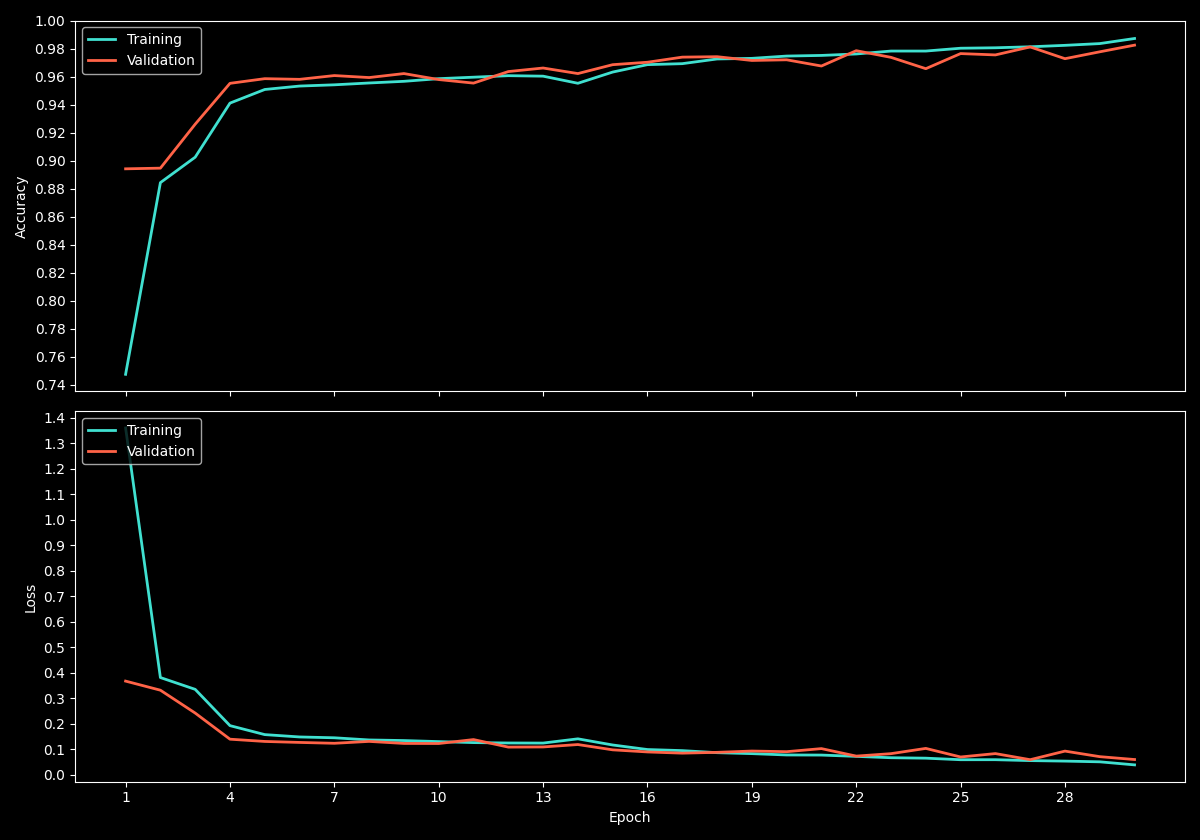

We employed the **loadpretrainedmodel** function, which loads the model parameters that we trained from the specified weights file and assigns the model to the selected computation device (CPU or GPU). The function accepts the path to the pretrained weights along with the target device as input arguments

In [20]:
model1=loadpretrainedmodel(config.model.pretrained_weights,device=device)

## 3.2 Adding a new classificartion head
The original model was trained on 50 classes, while our dataset has 43. Therefore, the pretrained network’s classification head was replaced with a new head compatible with our task.

The new head’s architecture is defined by head_dims, a list specifying the number of neurons in each fully connected layer. For our experiments, we used a two-layer head [256, 128] with a dropout of 0.5 between layers to reduce overfitting.

The final output layer has 43 neurons, matching the number of classes (controlled by the num_classes parameter in the configuration). The head is attached to the pretrained backbone using the addnewhead function, which takes the base model, head dimensions, and dropout probability as inputs.

In [21]:
model1=addnewhead(model1,model_config.head_dim,num_classes=config.model.num_classes,dropout=model_config.dropout)

## 3.3 Checking model parts
now we will print the model to check its architechture and parts

In [22]:
print(model1)

TorchVisionNet(
  (base): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

# 4. Training

## 4.1 Preparing for training
### 4.1.1 defining loss function
To address severe class imbalance, we compute class weights that give higher importance to underrepresented classes and lower weight to majority classes. This is done using the **compute_class_weights** function on the training set, and the resulting weight tensor is moved to the GPU for use with the loss function during training.

In [23]:
class_weights=compute_class_weights(train.dataset).to(device)

We use the CrossEntropyLoss as our loss function, we pass the computed class weights to it. These weights adjust the contribution of each class to the total loss, giving higher importance to underrepresented classes and lower importance to majority classes.

In [24]:
loss=torch.nn.CrossEntropyLoss(weight=class_weights)

### 4.1.2 Freezing the weights
In our first experiment, we freeze all pretrained layers and train only the added classification head using the **freeze_all_layers** function, which sets requires_grad = False for all the parameters firstly.Then The function allows unfreezing the last n basic blocks of the backbone (e.g., n = 1 unfreezes only Block 8, n = 2 unfreezes Blocks 8 and 7, etc.). The argument head_trainable controls whether the classification head is trainable (default True).


In [25]:
freeze_all_layers(model1,n=0,head_trainable=True)

### 4.1.3 Defining optimizer functions
We use the Adam optimizer for training. Two separate learning rates are employed: a smaller learning rate is assigned to the pretrained basic blocks, while a larger learning rate is applied to the classification head to encourage faster adaptation. Additionally, a weight decay of 1e-4
 is applied to all parameters to regularize the model and prevent overfitting.

In [26]:
# Optimizer only on trainable params
 # last block of backbone
optimizer = torch.optim.Adam([
    {"params": model1.head.parameters(), "lr":float(config.training.lr_head)}       # new head
], weight_decay=1e-4)


## 4.2 Training the model
now we come to the most important part which is training the model


### 4.2.1 Intiating Mlflow
We define the location to save the data from our experiments using the function **initiate_mlflow**. This function allows us to specify the directory where all experiment data, such as metrics, parameters, and artifacts, will be stored for later analysis and reproducibility.

In [27]:
initate_mlflow("/content/Expirenments")

##4.3 First Expirement

In the first expirement we will freeze the weights of all layers of the pre-trained model and we will train only the classification head

### 4.3.1 Doing the expirement
For running the first expirment we employ the **run_expirement** function that accepts the following arguments
1.   Model: The neural network architecture to be trained.
2.   Experiment Name: A unique name assigned to the training experiment for tracking and reproducibility.
3.   Class Names: The list of target classes used in the classification task.
4.   Training DataLoader: The data loading pipeline for the training dataset, including batch size, shuffling, and preprocessing.
5.   Criterion (Loss Function): The loss function used to measure the difference between predictions and ground truth labels.
6.   Parameters (Configuration File): The set of hyperparameters and configuration settings that control the training process (e.g., learning rate, batch size, number of epochs, etc.).
7.   Optimizer: The optimization algorithm used to update model weights during training (e.g., SGD, Adam).
8.   Scheduler: The learning rate scheduling strategy used to adjust the learning rate during training.
9.   Number of Epochs: The total number of complete passes through the training dataset.
10.  Device: The hardware used for training (e.g., CPU or GPU).
11.  Save Path: The directory path where the trained model checkpoints will be stored.

During the training the training loss training accuracy ,validation loss validation accuracy,the hyperparameter used for training and the learning and accuracy curve the classification report and the confusion matrix are all saved in the folder we specified in the initate_mlflow function


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/06 00:49:23 INFO mlflow.tracking.fluent: Experiment with name 'training Only classification head' does not exist. Creating a new experiment.
Training batch: 100%|██████████| 221/221 [00:07<00:00, 28.55it/s]

Training the model:  10%|█         | 1/10 [00:08<01:20,  8.93s/it]

Epoch [1/10] Train Loss: 2.4058, Train Acc: 0.3462 Val Loss: 1.4852, Val Acc: 0.5301



Training batch: 100%|██████████| 221/221 [00:06<00:00, 33.72it/s]

Training the model:  20%|██        | 2/10 [00:16<01:05,  8.15s/it]

Epoch [2/10] Train Loss: 1.4538, Train Acc: 0.5426 Val Loss: 1.1039, Val Acc: 0.6977



Training batch: 100%|██████████| 221/221 [00:06<00:00, 33.25it/s]

Training the model:  30%|███       | 3/10 [00:24<00:55,  7.95s/it]

...


Training batch: 100%|██████████| 221/221 [00:06<00:00, 32.90it/s]

Training the model:  90%|█████████ | 9/10 [01:10<00:07,  7.76s/it]

Epoch [9/10] Train Loss: 0.8980, Train Acc: 0.6759 Val Loss: 1.0436, Val Acc: 0.6410



Training batch: 100%|██████████| 221/221 [00:06<00:00, 33.24it/s]

Training the model: 100%|██████████| 10/10 [01:18<00:00,  7.84s/it]


Epoch [10/10] Train Loss: 0.8776, Train Acc: 0.6726 Val Loss: 1.0236, Val Acc: 0.6906


Validating: 100%|██████████| 36/36 [00:01<00:00, 33.44it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len

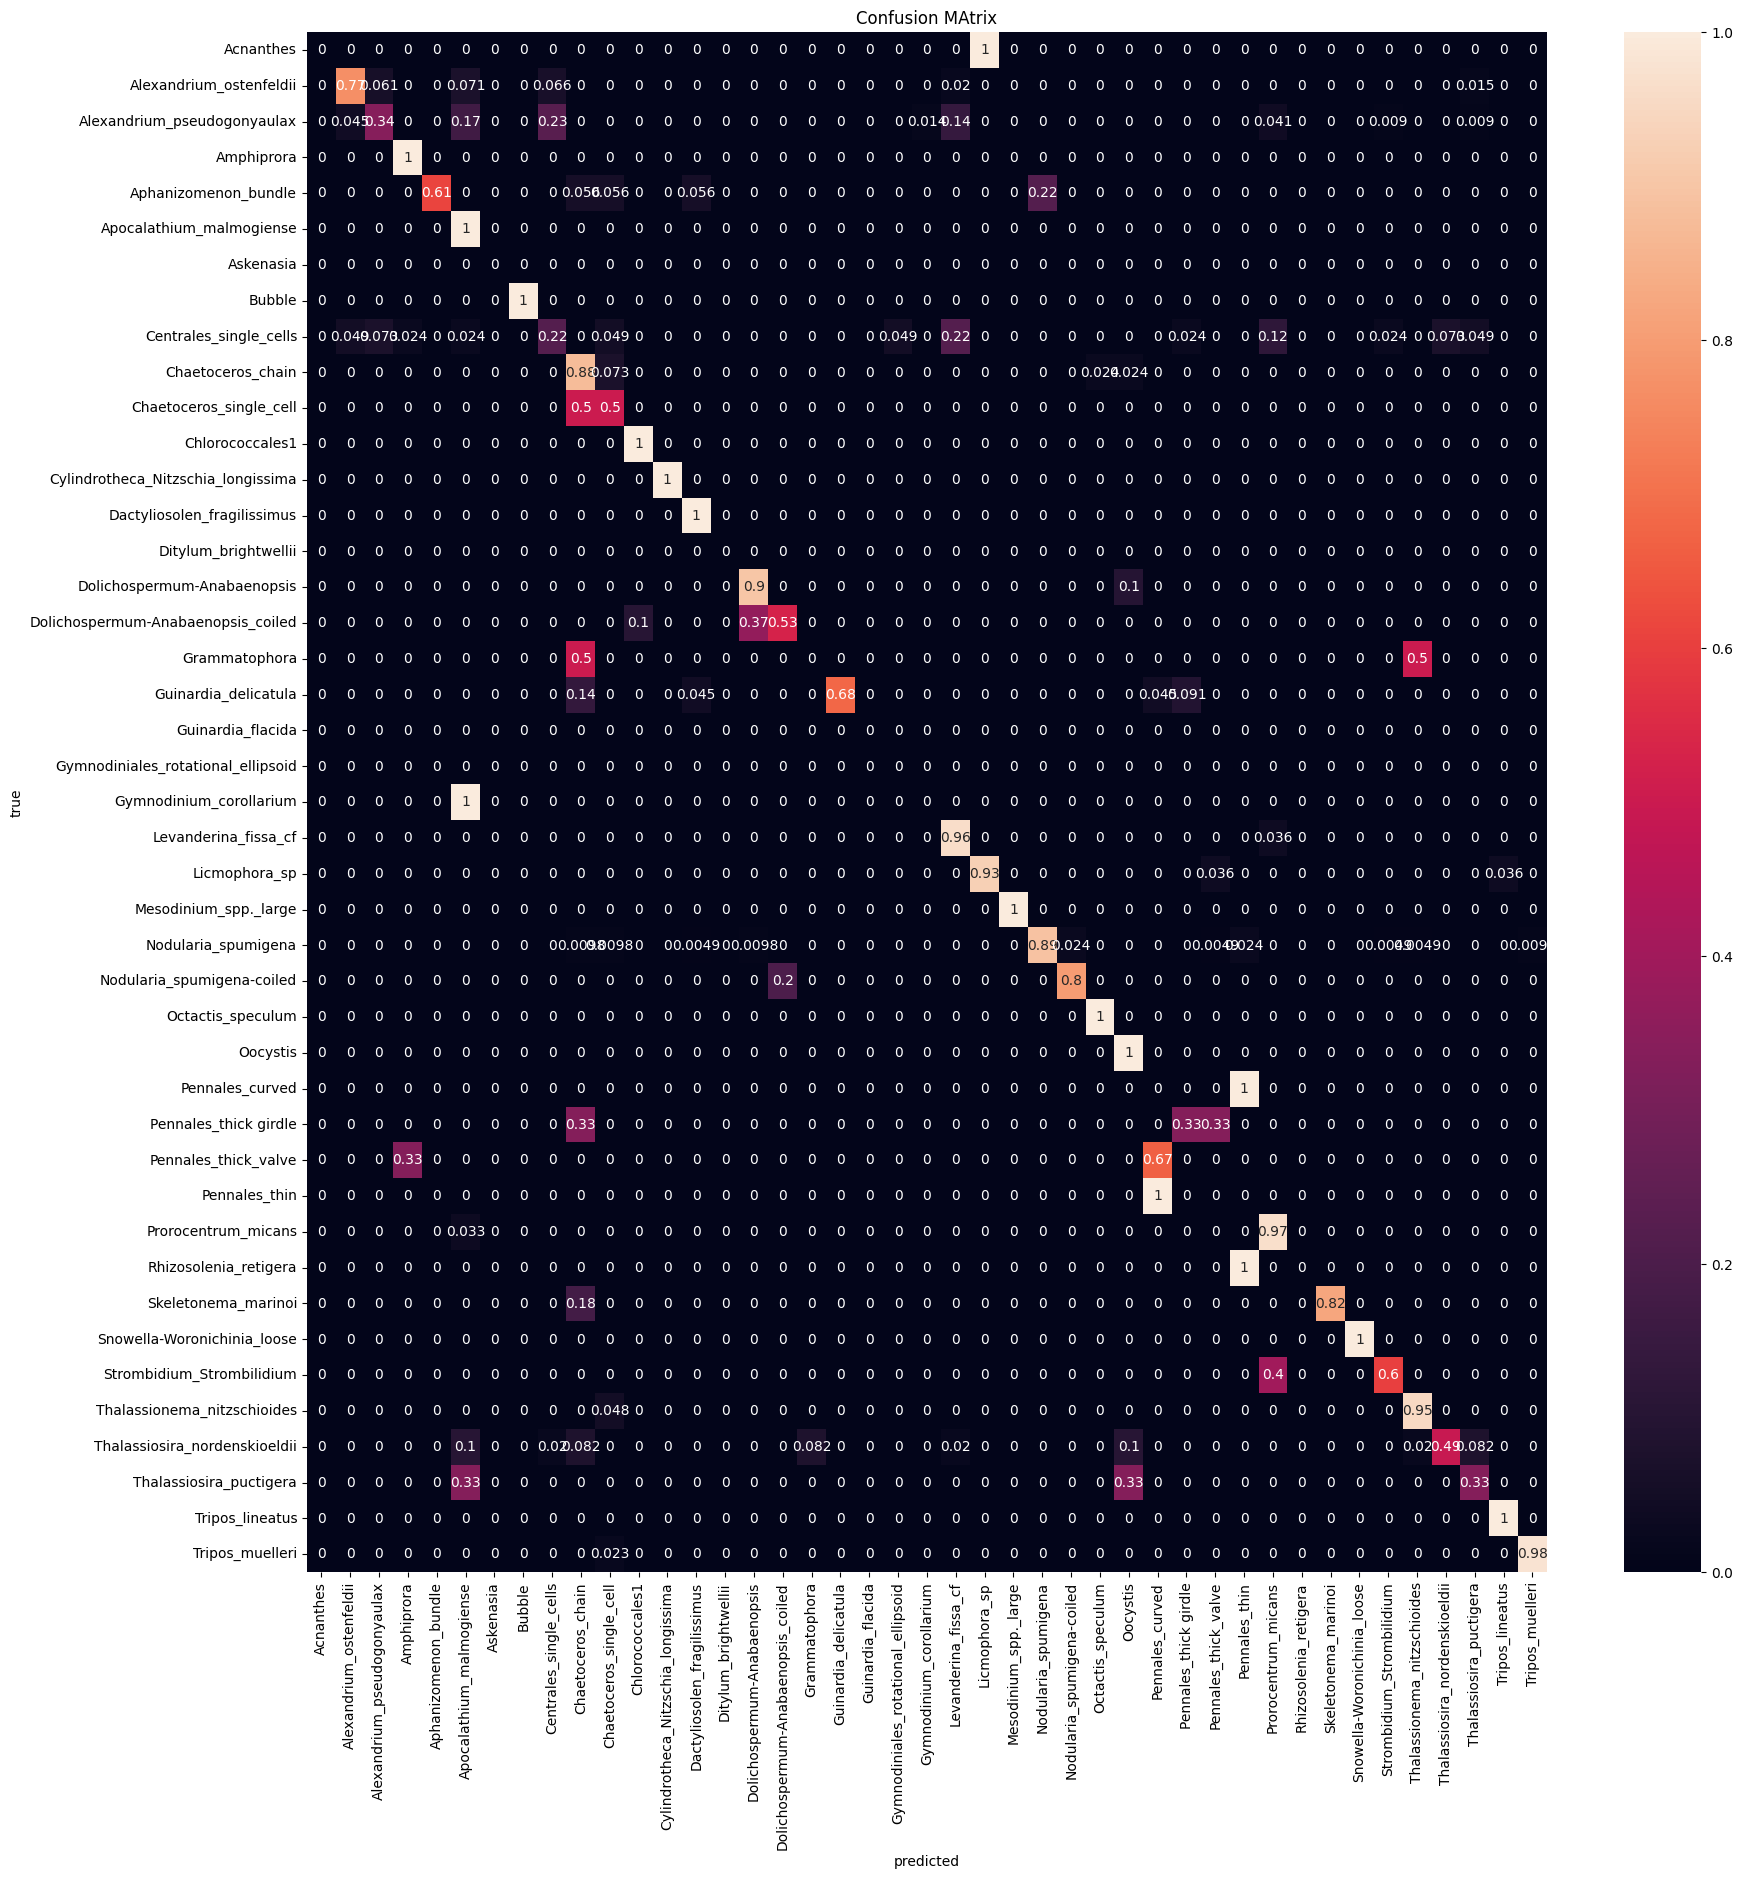

In [28]:
config.training.num_epochs=10
history1=run_expirement(model=model1,expirement_name="training Only classification head",class_names=IOW_dataset.classes,train_loader=train,val_loader=val,criterion=loss,params=config,
               optimizer=optimizer,scheduler=None,num_epochs=training_config.num_epochs,device=device,save_path=config.training.save_path)

###4.3.2 Evaluating the results of the first expirement

We assess the model on the test set using the validate_multiclass function, which returns the loss, accuracy, and all true and predicted labels.

In [29]:
val_loss,val_acc,all_labels,all_preds=validate_multiclass(
    model=model1,
    dataloader=val,
    criterion=loss,
   device=device)

Validating: 100%|██████████| 36/36 [00:01<00:00, 34.60it/s]


In [30]:
val_acc

0.6906028368794326

We will plot the loss and the accuracy curves using the function **plot_learning_curv**e we pass the history dictionary that was returned from the run_expirement function

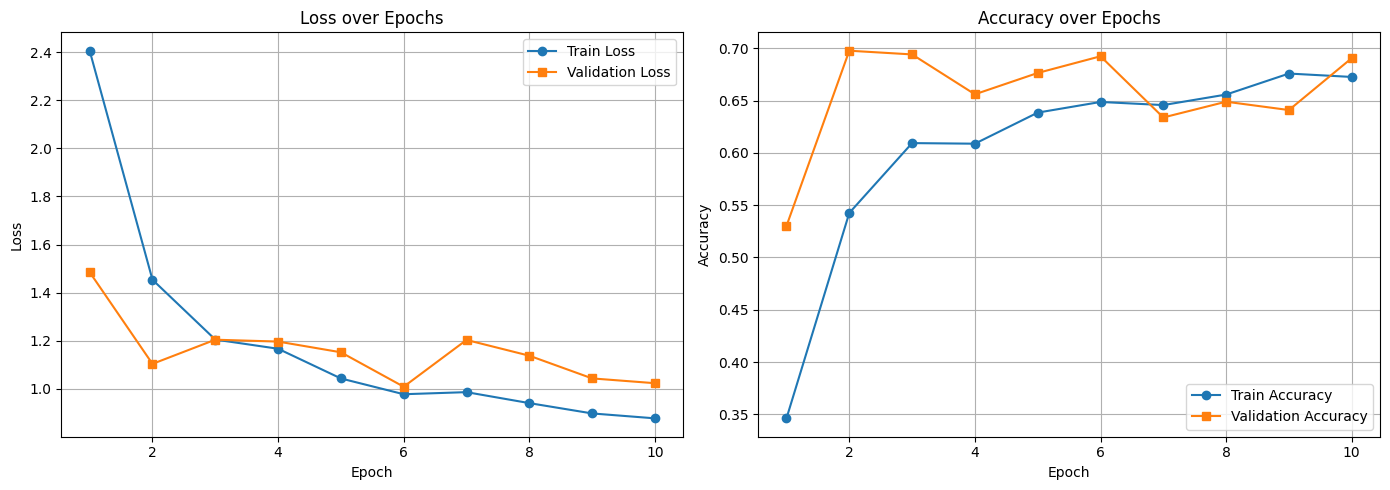

In [31]:
plot_learning_curve(history1,save_path=None,show=True)

We wil plot the confusion matrix using the function plot_confusion_matrix


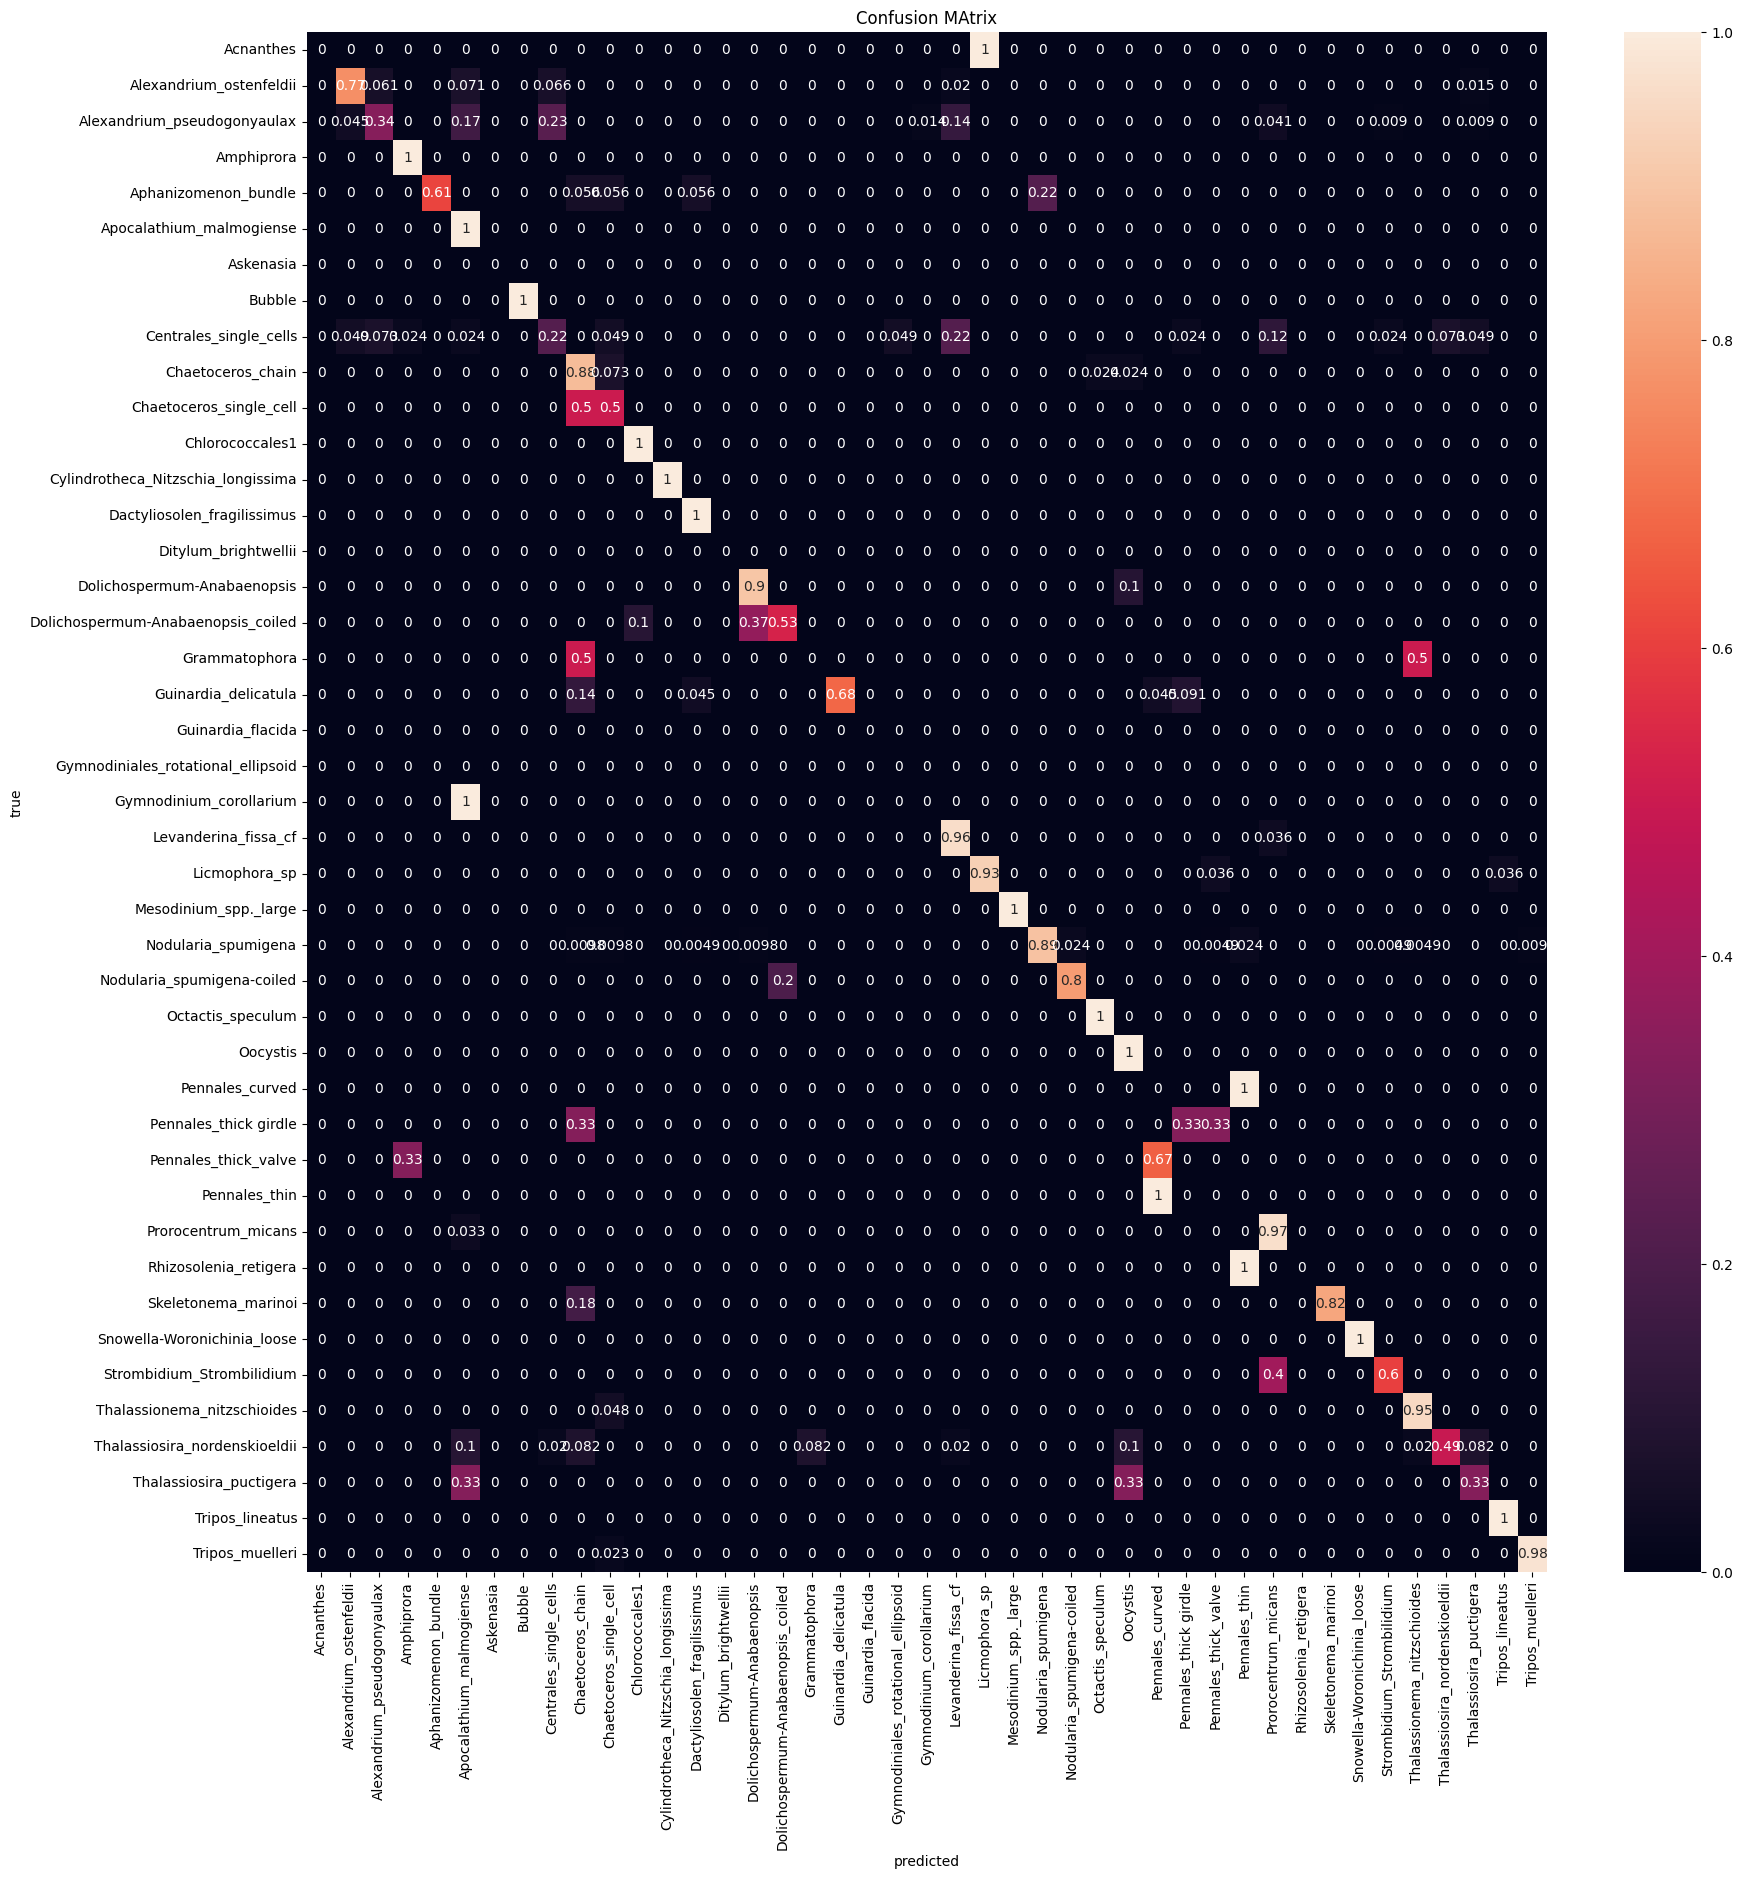

In [32]:
plot_confusion_matrix(all_labels,all_preds,class_names=IOW_dataset.classes,figsize=(20,20))

# **Obeservations from the confusion matrix**


*   Classes with more samples tended to perform better.
*   Some classes were predicted with 100% accuracy, but this is misleading because they had only one or two samples in the test set.
* Classes belonging to the same taxa were often heavily confused with each other.











In [34]:
print(save_classification_report(all_labels,all_preds,class_names=IOW_dataset.classes,save_path=None))

                                    precision    recall  f1-score   support

                         Acnanthes       0.00      0.00      0.00         1
           Alexandrium_ostenfeldii       0.93      0.77      0.84       198
       Alexandrium_pseudogonyaulax       0.83      0.34      0.48       222
                        Amphiprora       0.50      1.00      0.67         2
              Aphanizomenon_bundle       1.00      0.61      0.76        18
          Apocalathium_malmogiense       0.04      1.00      0.09         3
                         Askenasia       0.00      0.00      0.00         0
                            Bubble       1.00      1.00      1.00         7
            Centrales_single_cells       0.12      0.22      0.16        41
                 Chaetoceros_chain       0.67      0.88      0.76        41
           Chaetoceros_single_cell       0.09      0.50      0.15         2
                   Chlorococcales1       0.29      1.00      0.44         2
Cylindrothe

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

From the classification report we see the following observations

*   Classes with more examples examples in the test set acchieved moderate to good performance  
*   The rare classes performed poorly
*   Performance is reasonably good when accounting for class imbalance.
*   Performance drops significantly when all classes are treated equally.
*   The large gap between weighted avg  and macro avg indicates strong class imbalance.

###4.4 Second expirement
In this expirement we will train the classification head and the last basic block

## 4.4.1 Doing the expirement

We reload the pretrained weights that we got from the Finnish model

In [35]:
model2=loadpretrainedmodel(config.model.pretrained_weights,device=device)

We add to the model a new head with dimensions same as in expirement one [256,128] and dropout of 0.5

In [36]:
model2=addnewhead(model2,dims=config.model.head_dim,num_classes=43)

“We froze the weights of all layers except for the classification head and the last basic block of the pre-trained ResNet18 model.”

In [37]:
freeze_all_layers(model2,n=1,head_trainable=True)

We define the Adam optimizer function with two learning rates

*   1e-3 for the head
*   1e-4 for the base
*   and weight decay of 1e-4

In [38]:
optimizer = torch.optim.Adam([
    {"params": model2.head.parameters(), "lr":float(config.training.lr_head)},
    {"params":model2.base[7].parameters(),"lr":float(config.training.lr_base)},
], weight_decay=1e-4)
training_config.num_epochs=16

2026/03/06 00:56:10 INFO mlflow.tracking.fluent: Experiment with name 'head and last 1 basic blocks' does not exist. Creating a new experiment.
Training batch: 100%|██████████| 221/221 [00:06<00:00, 32.71it/s]

Training the model:   6%|▋         | 1/16 [00:07<01:58,  7.90s/it]

Epoch [1/16] Train Loss: 1.8347, Train Acc: 0.4768 Val Loss: 0.9620, Val Acc: 0.6986



Training batch: 100%|██████████| 221/221 [00:06<00:00, 33.19it/s]

Training the model:  12%|█▎        | 2/16 [00:15<01:49,  7.80s/it]

Epoch [2/16] Train Loss: 0.6941, Train Acc: 0.7248 Val Loss: 0.7874, Val Acc: 0.7199



Training batch: 100%|██████████| 221/221 [00:06<00:00, 31.62it/s]

Training the model:  19%|█▉        | 3/16 [00:23<01:43,  7.93s/it]

...


Training batch: 100%|██████████| 221/221 [00:06<00:00, 32.78it/s]

Training the model:  94%|█████████▍| 15/16 [01:58<00:07,  7.89s/it]

Epoch [15/16] Train Loss: 0.1828, Train Acc: 0.9073 Val Loss: 0.8499, Val Acc: 0.8449



Training batch: 100%|██████████| 221/221 [00:06<00:00, 32.52it/s]

Training the model: 100%|██████████| 16/16 [02:06<00:00,  7.89s/it]


Epoch [16/16] Train Loss: 0.1756, Train Acc: 0.9082 Val Loss: 0.6754, Val Acc: 0.9043


Validating: 100%|██████████| 36/36 [00:01<00:00, 32.06it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len

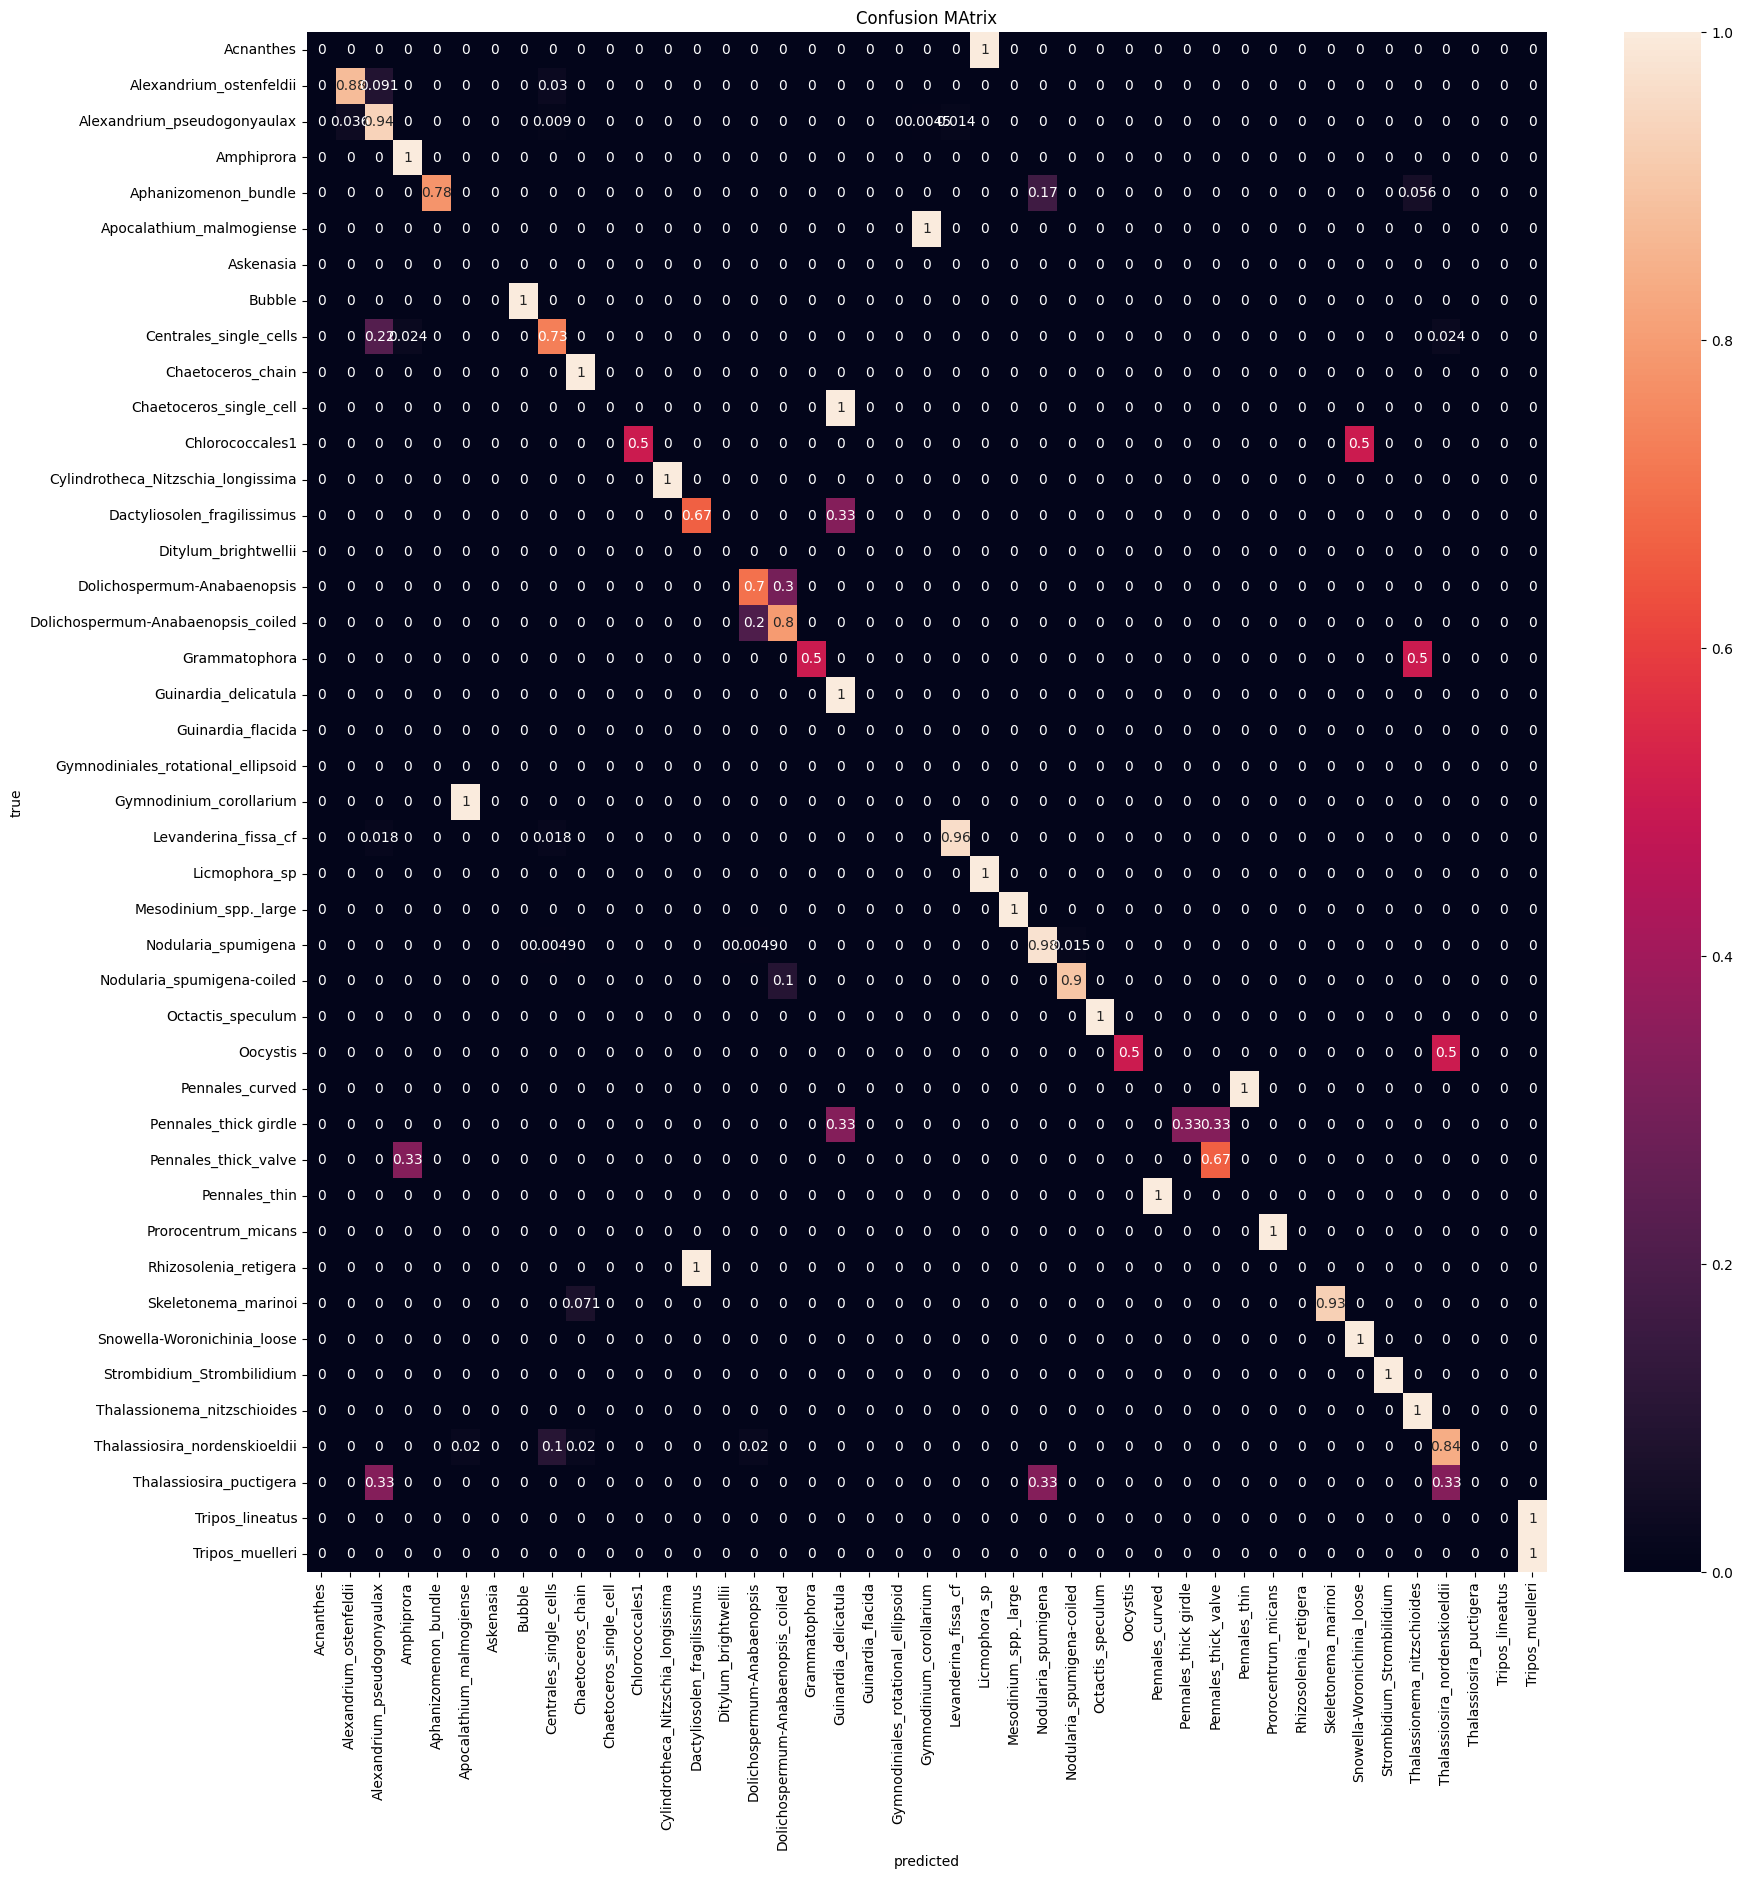

In [39]:
history2=run_expirement(model=model2,expirement_name="head and last 1 basic blocks",class_names=IOW_dataset.classes,train_loader=train,val_loader=val,criterion=loss,params=config,
               optimizer=optimizer,scheduler=None,num_epochs=training_config.num_epochs,device=device,save_path=config.training.save_path)

###4.4.2 Evaluating the results of the second expirement

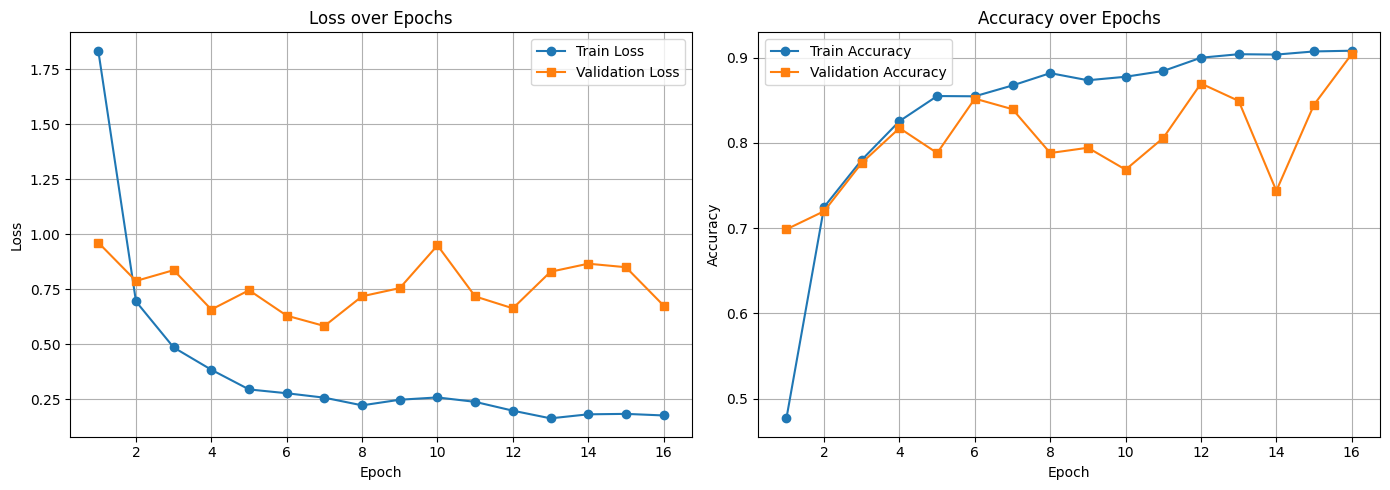

In [40]:
plot_learning_curve(history2,None,True)

In [41]:
val_loss2,val_acc2,all_labels2,all_preds2=validate_multiclass(
    model=model2,
    dataloader=val,
    criterion=loss,
   device=device)

Validating: 100%|██████████| 36/36 [00:01<00:00, 33.22it/s]


In [42]:
val_acc2

0.9042553191489362

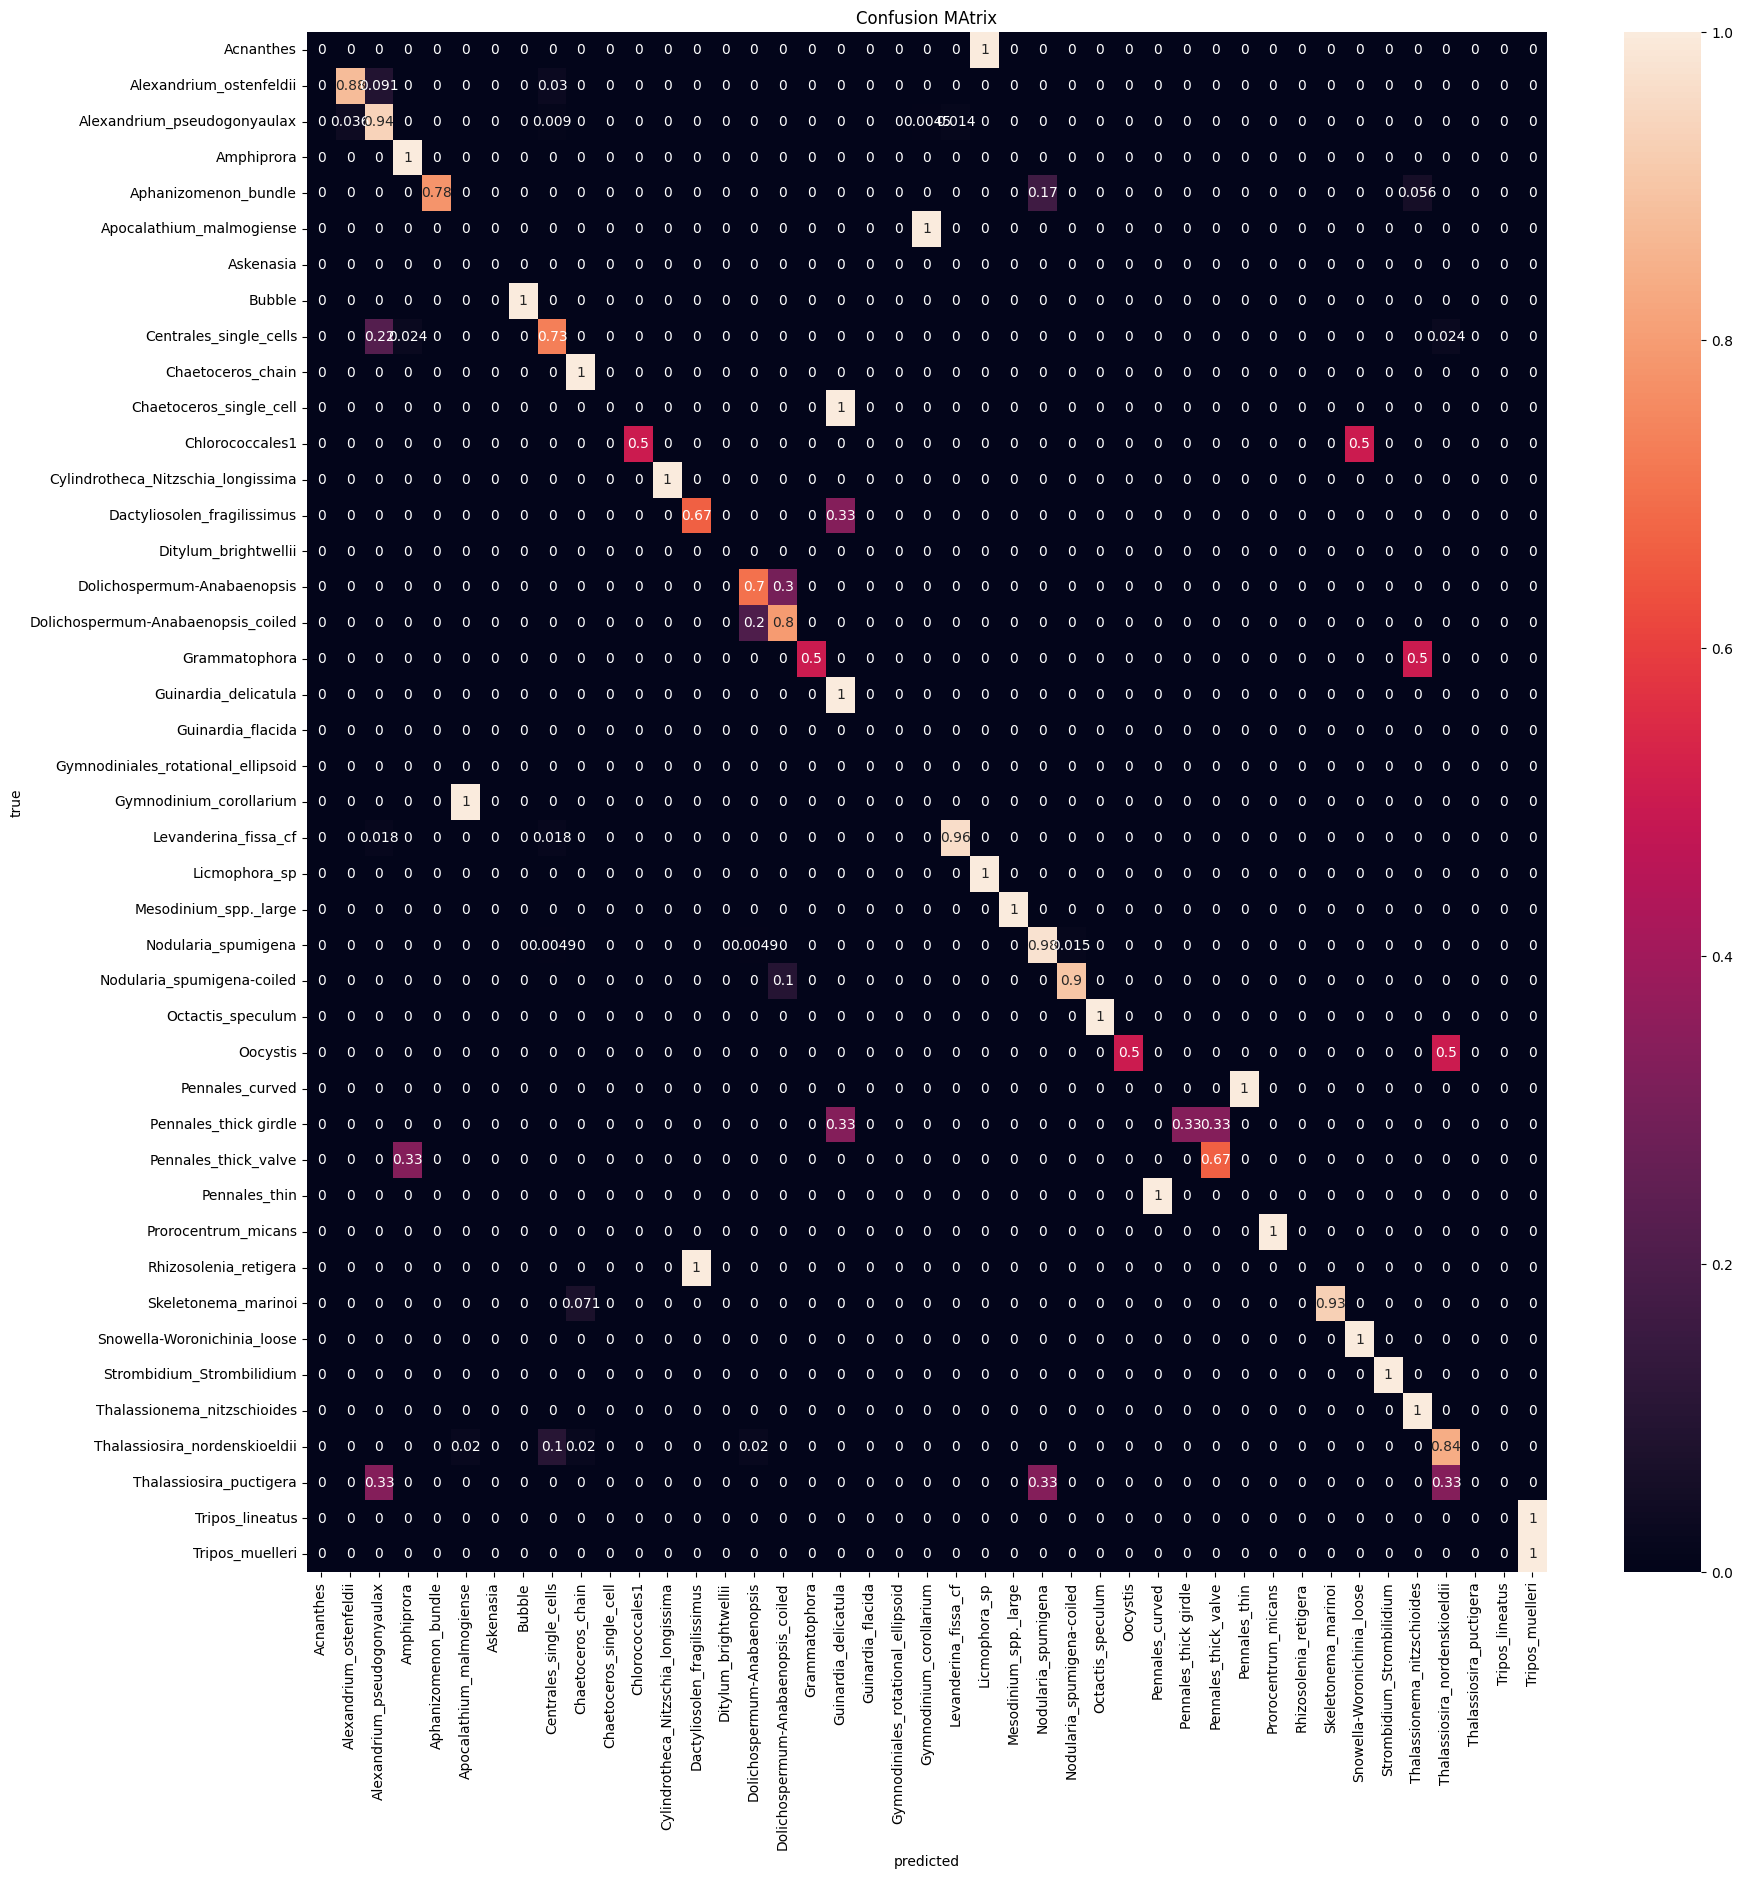

In [43]:
plot_confusion_matrix(all_labels2,all_preds2,class_names=idx_to_cls.values(),figsize=(20,20))

In [44]:
print(save_classification_report(y_true=all_labels2,y_pred=all_preds2,class_names=IOW_dataset.classes,save_path=None))

                                    precision    recall  f1-score   support

                         Acnanthes       0.00      0.00      0.00         1
           Alexandrium_ostenfeldii       0.96      0.88      0.92       198
       Alexandrium_pseudogonyaulax       0.88      0.94      0.91       222
                        Amphiprora       0.50      1.00      0.67         2
              Aphanizomenon_bundle       1.00      0.78      0.88        18
          Apocalathium_malmogiense       0.00      0.00      0.00         3
                         Askenasia       0.00      0.00      0.00         0
                            Bubble       1.00      1.00      1.00         7
            Centrales_single_cells       0.67      0.73      0.70        41
                 Chaetoceros_chain       0.93      1.00      0.96        41
           Chaetoceros_single_cell       0.00      0.00      0.00         2
                   Chlorococcales1       1.00      0.50      0.67         2
Cylindrothe

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

Although updating the classification layer and the final basic block improved overall accuracy as well as weighted precision and recall, the model continues to struggle with classes that have very few samples.

We will visualize the classes that the model confuses using the show_misclassified method to better understand the similarities between them.

  6%|▌         | 2/36 [00:00<00:07,  4.39it/s]


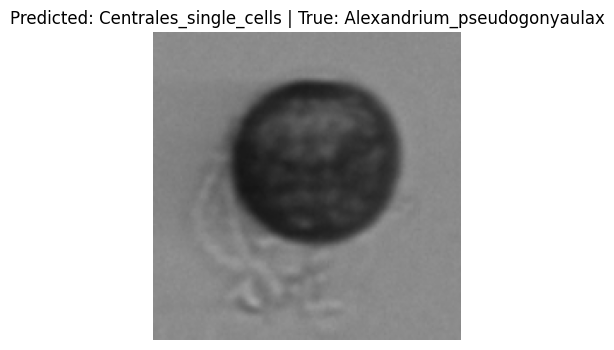

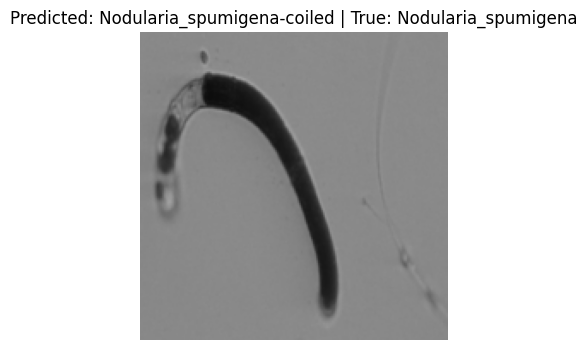

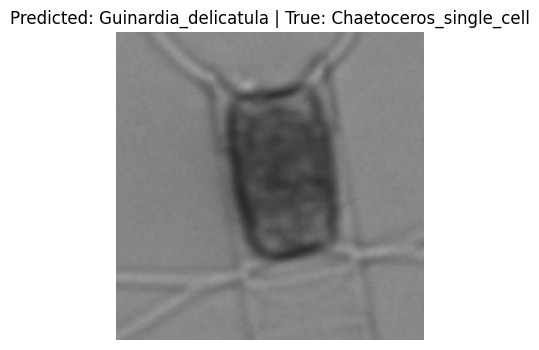

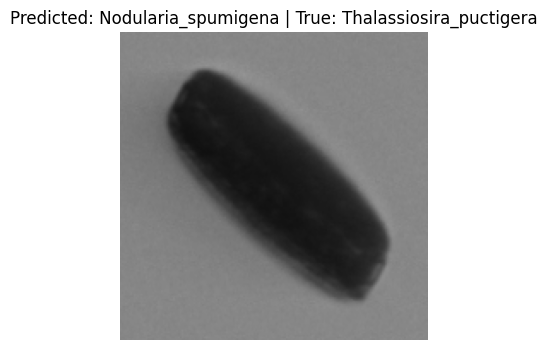

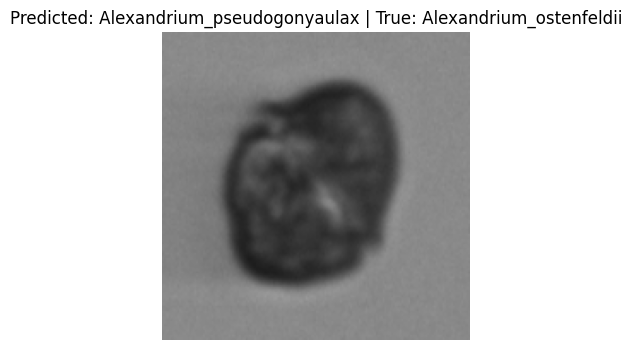

In [45]:

show_misclassified(model2,val,IOW_dataset.classes,num_images=5,device=device)

#5. Explainable AI
“We use the implement_integrated function to apply the Integrated Gradients method, an explainable AI technique. This method highlights the regions of the images that contribute most to the model’s classification decisions, helping the end user better understand and trust the model.”

  0%|          | 0/36 [00:00<?, ?it/s]

0.04313725605607033 0.5960784554481506


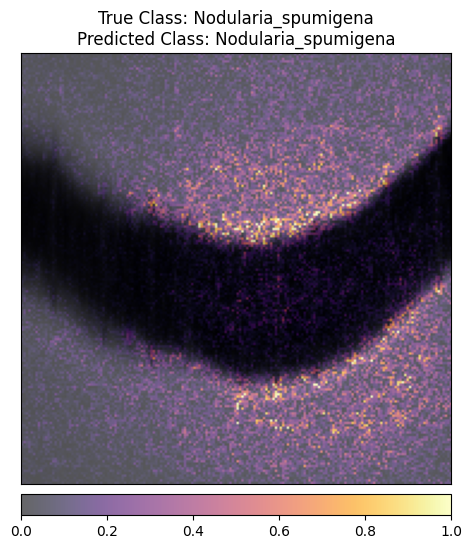

0.12941177189350128 0.6666666865348816


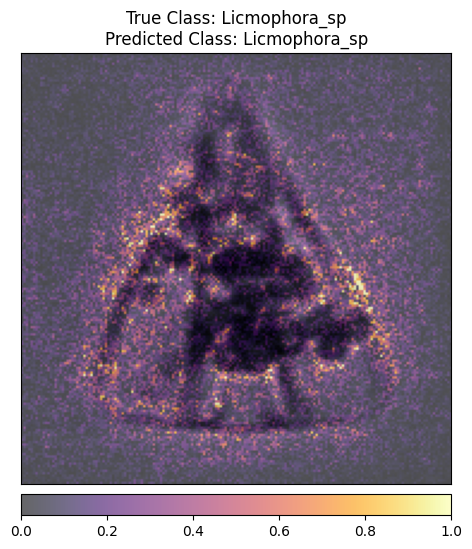

0.10196078568696976 0.5921568870544434


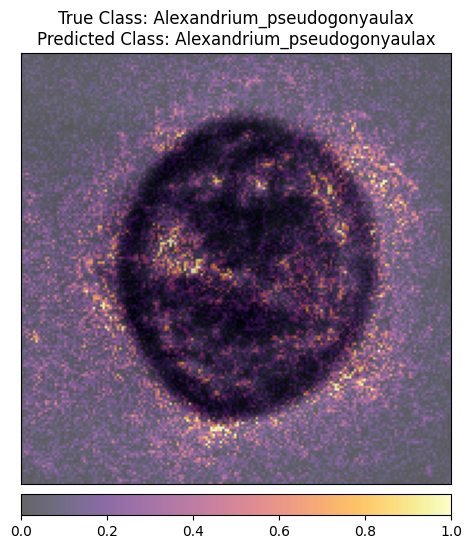

0.09803921729326248 0.5960784554481506


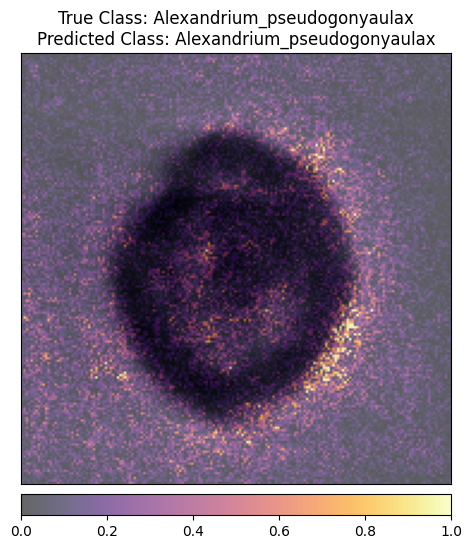

0.03921568766236305 0.5529412031173706


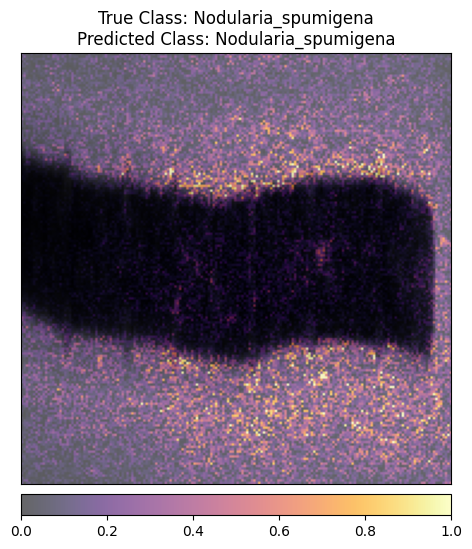

0.05882352963089943 0.615686297416687


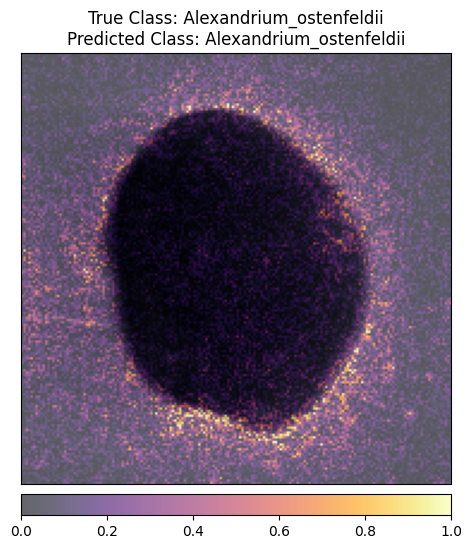

0.04313725605607033 0.5921568870544434


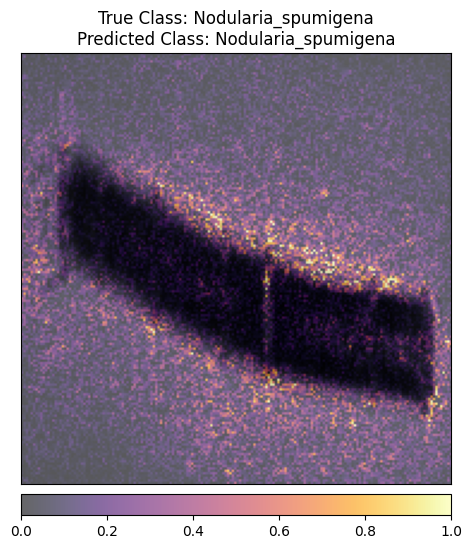

0.09803921729326248 0.6039215922355652


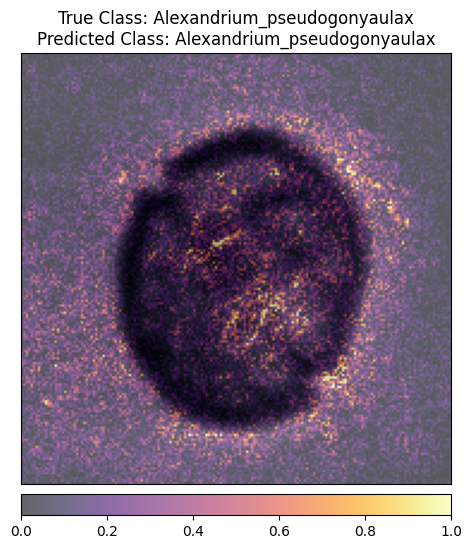

0.11372549086809158 0.6039215922355652


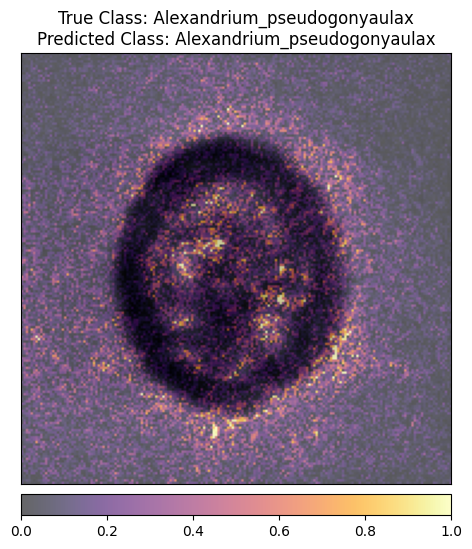

0.0941176488995552 0.6509804129600525


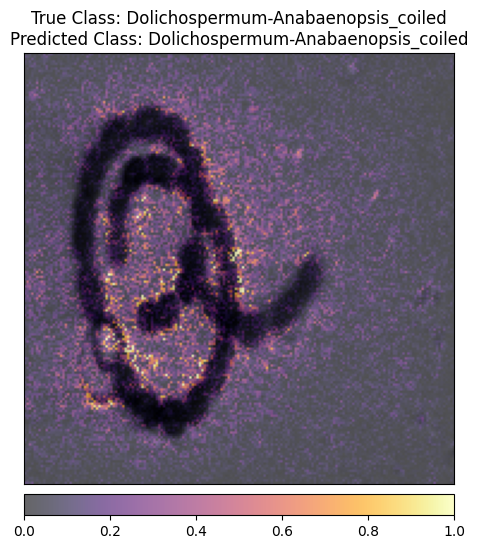

  0%|          | 0/36 [00:07<?, ?it/s]


In [46]:
implement_integrated(model2,val,num_images=10,device=device,class_names=IOW_dataset.classes)

# 6.Conclusion
Due to the severe class imbalance in our dataset, the model performed well on the classes with more samples, achieving high precision and recall for these classes. However, the model struggled to distinguish between classes that are visually similar. To address this issue, retraining the model with additional data for underrepresented classes could improve performance. Another possible approach is hierarchical classification, where images are first classified into broader taxonomic groups and then into specific sub-classes, which is suitable since many classes in the dataset belong to the same taxa. Additionally, using larger pretrained models, such as ResNet34 or ResNet50, and fine-tuning them on our data may further enhance performance.